#Importing Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Importing libraries

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

#Data Preprocessing

##Training Image preprocessing

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 359 files belonging to 34 classes.


##Validation Image Preprocessing

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 359 files belonging to 34 classes.


#Building Model

In [10]:
cnn = tf.keras.models.Sequential()

##Building Convolution Layer

In [11]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[64,64,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [13]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [14]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [15]:
cnn.add(tf.keras.layers.Flatten())

In [16]:
cnn.add(tf.keras.layers.Dense(units=512,activation='relu'))

In [17]:
cnn.add(tf.keras.layers.Dense(units=256,activation='relu'))

In [18]:
cnn.add(tf.keras.layers.Dropout(0.5)) #To avoid overfitting

In [23]:
#Output Layer
cnn.add(tf.keras.layers.Dense(units=34,activation='softmax'))

#Compiling and Training Phase

In [24]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         8,995 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │         1,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,630,155 (25.29 MB)

 Trainable params: 6,630,155 (25.29 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=32)

Epoch 1/32
12/12 ━━━━━━━━━━━━━━━━━━━━ 103s 8s/step - accuracy: 0.0489 - loss: 3.5395 - val_accuracy: 0.0279 - val_loss: 3.5444
Epoch 2/32
12/12 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.0415 - loss: 3.5404 - val_accuracy: 0.0279 - val_loss: 3.5380
Epoch 3/32
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.0257 - loss: 3.5359 - val_accuracy: 0.0279 - val_loss: 3.5369
Epoch 4/32
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.0340 - loss: 3.5325 - val_accuracy: 0.0279 - val_loss: 3.5357
Epoch 5/32
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.0368 - loss: 3.5187 - val_accuracy: 0.0279 - val_loss: 3.5345
Epoch 6/32
12/12 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.0491 - loss: 3.5267 - val_accuracy: 0.0557 - val_loss: 3.5334
Epoch 7/32
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.0441 - loss: 3.5309 - val_accuracy: 0.0557 - val_loss: 3.5324
Epoch 8/32
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.0656 - loss: 3.5181 - val_accuracy: 0.0557 - val_loss

##Evaluating Model

In [27]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.0585 - loss: 3.5226
Training accuracy: 0.055710308253765106


In [28]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 940ms/step - accuracy: 0.0466 - loss: 3.5231
Validation accuracy: 0.055710308253765106


##Saving Model

In [29]:
cnn.save('trained_model.h5')

In [30]:
training_history.history #Return Dictionary of history

{'accuracy': [0.033426184207201004,
  0.03064066916704178,
  0.02506963722407818,
  0.03064066916704178,
  0.03064066916704178,
  0.055710308253765106,
  0.05292478948831558,
  0.05292478948831558,
  0.055710308253765106,
  0.04735375940799713,
  0.05013927444815636,
  0.038997214287519455,
  0.033426184207201004,
  0.027855154126882553,
  0.038997214287519455,
  0.044568244367837906,
  0.016713092103600502,
  0.016713092103600502,
  0.019498607143759727,
  0.033426184207201004,
  0.02506963722407818,
  0.04178272932767868,
  0.05013927444815636,
  0.044568244367837906,
  0.03064066916704178,
  0.05292478948831558,
  0.044568244367837906,
  0.044568244367837906,
  0.04735375940799713,
  0.038997214287519455,
  0.05849582329392433,
  0.04735375940799713],
 'loss': [3.5479483604431152,
  3.5361111164093018,
  3.5383732318878174,
  3.5370941162109375,
  3.5272438526153564,
  3.5311527252197266,
  3.535069227218628,
  3.533216714859009,
  3.5276389122009277,
  3.546572685241699,
  3.527270

In [31]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [32]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


##Calculating Accuracy of Model Achieved on Validation set

In [33]:
print("Validation set Accuracy: {} %".format(training_history.history['val_accuracy'][-1]*100))

Validation set Accuracy: 5.571030825376511 %


#Accuracy Visualization

##Training Visualization

In [34]:
#training_history.history['accuracy']

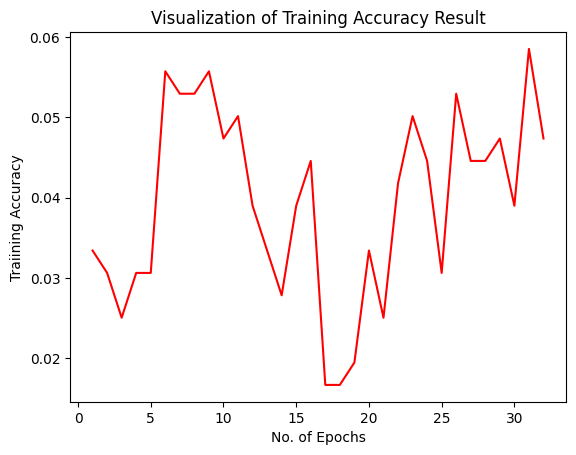

In [35]:
epochs = [i for i in range(1,33)]
plt.plot(epochs,training_history.history['accuracy'],color='red')
plt.xlabel('No. of Epochs')
plt.ylabel('Traiining Accuracy')
plt.title('Visualization of Training Accuracy Result')
plt.show()

##Validation Accuracy

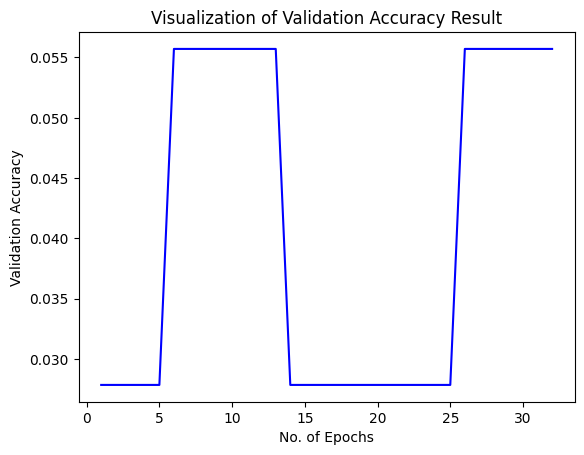

In [36]:
plt.plot(epochs,training_history.history['val_accuracy'],color='blue')
plt.xlabel('No. of Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Visualization of Validation Accuracy Result')
plt.show()

##Test set Evaluation

In [37]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 359 files belonging to 34 classes.


In [38]:
test_loss,test_acc = cnn.evaluate(test_set)
print('Test accuracy:', test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 870ms/step - accuracy: 0.0886 - loss: 3.5197
Test accuracy: 0.055710308253765106


In [39]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [40]:
cnn = tf.keras.models.load_model('/content/trained_model.h5')

In [41]:
import os

# To diagnose the error, let's list the conte/content/drive/MyDrive/Fruit_Vegetable_Recognition'nts of the parent directory
# to ensure the 'test' directory exists and the path is correct.
print(os.listdir('/content/drive/MyDrive/test'))

# Original code (commented out for diagnosis):
# test_set = tf.keras.utils.image_dataset_from_directory(
#     '/content/drive/MyDrive/test',
#     labels="inferred",
#     label_mode="categorical",
#     class_names=None,
#     color_mode="rgb",
#     batch_size=32,
#     image_size=(64, 64),
#     shuffle=True,
#     seed=None,
#     validation_split=None,
#     subset=None,
#     interpolation="bilinear",
#     follow_links=False,
#     crop_to_aspect_ratio=False
# )

['sweetpotato', 'raddish', 'turnip', 'sweetcorn', 'tomato', 'soy beans', 'spinach', 'potato', 'pomegranate', 'orange', 'paprika', 'peas', 'onion', 'pineapple', 'lemon', 'lettuce', 'mango', 'kiwi', 'cucumber', 'garlic', 'ginger', 'grapes', 'corn', 'eggplant', 'jalepeno', 'carrot', 'cauliflower', 'chilli pepper', 'capsicum', 'beetroot', 'cabbage', 'bell pepper', 'banana', 'apple', '.ipynb_checkpoints']


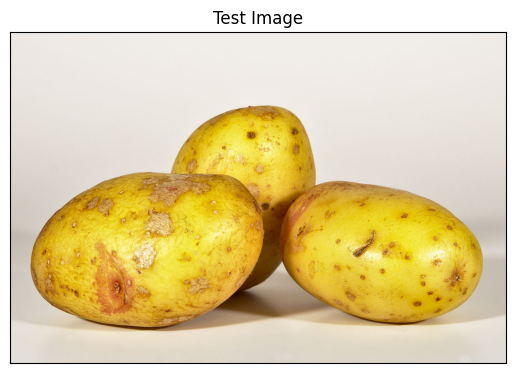

In [51]:
#Test Image Visualization
import cv2
image_path = '/content/drive/MyDrive/test/potato/Image_1.jpg'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [52]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(64,64))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [53]:
print(predictions)

[[0.02552747 0.0232825  0.02440765 0.02766747 0.0271293  0.02805248
  0.02461781 0.03547525 0.02508728 0.02563649 0.02911055 0.02709116
  0.03491153 0.03484418 0.03380455 0.02651588 0.02501108 0.02622082
  0.03469466 0.03274442 0.02481959 0.03151271 0.03377528 0.02726952
  0.03640281 0.02650769 0.03908303 0.02586029 0.02797171 0.02447993
  0.03099694 0.02877627 0.03642986 0.03428194]]


In [54]:
test_set.class_names

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip']

In [55]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

26


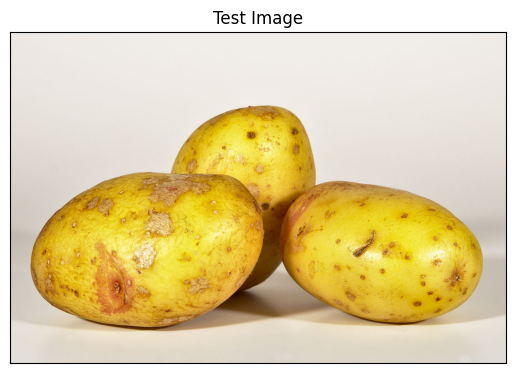

In [56]:
# Displaying the image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [57]:
#Single image Prediction
print("It's a {}".format(test_set.class_names[result_index]))

It's a potato


In [58]:
print("It's a {}".format(test_set.class_names[result_index]))

It's a potato
